In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

print("All imports OK")

#setting default hache dir 
import os
os.environ["HF_DATASETS_CACHE"] = "/mnt/D/hf_datasets_cache"

/mnt/D/pip_envs/asr/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK


In [2]:
import sys
print(sys.executable)

/mnt/D/pip_envs/asr/bin/python


In [3]:
!export HF_DATASETS_CACHE="/mnt/D/hf_datasets_cache"


In [4]:
train_ds = load_dataset("MohamedRashad/common-voice-18-arabic", split="train")
val_ds   = load_dataset("MohamedRashad/common-voice-18-arabic", split="validation")
test_ds  = load_dataset("MohamedRashad/common-voice-18-arabic", split="test")

print(f"Train samples      : {len(train_ds)}")
print(f"Validation samples : {len(val_ds)}")
print(f"Test samples       : {len(test_ds)}")
print(f"\nColumns: {train_ds.column_names}")

Train samples      : 28410
Validation samples : 10471
Test samples       : 10471

Columns: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment', 'variant']


In [6]:
# Always index the sample FIRST, then access audio — avoids decoding the whole dataset
sample = train_ds[0]

audio_array = sample["audio"]["array"]
sample_rate = sample["audio"]["sampling_rate"]
transcript  = sample["sentence"]

print(f"Transcript  : {transcript}")
print(f"Sample rate : {sample_rate} Hz")
print(f"Duration    : {len(audio_array)/sample_rate:.2f} seconds")
print(f"Up votes    : {sample['up_votes']}")
print(f"Down votes  : {sample['down_votes']}")
print(f"Speaker age : {sample['age']}")
print(f"Gender      : {sample['gender']}")

Transcript  : محصول الطماطم جودته عالية.
Sample rate : 48000 Hz
Duration    : 4.94 seconds
Up votes    : 2
Down votes  : 1
Speaker age : twenties
Gender      : male_masculine


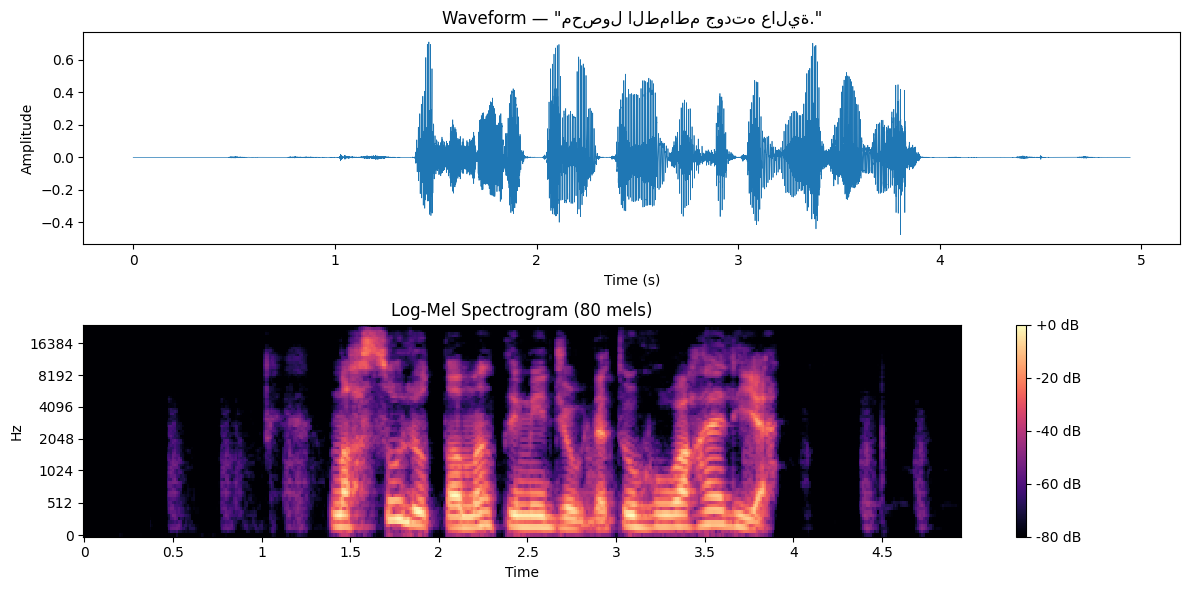

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Waveform
time_axis = np.linspace(0, len(audio_array)/sample_rate, len(audio_array))
axes[0].plot(time_axis, audio_array, linewidth=0.5)
axes[0].set_title(f'Waveform — "{transcript}"')
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

# Log-Mel Spectrogram
mel_spec = librosa.feature.melspectrogram(
    y=audio_array.astype(np.float32),
    sr=sample_rate,
    n_mels=80,
    fmax=8000
)
mel_db = librosa.power_to_db(mel_spec, ref=np.max)
img = librosa.display.specshow(mel_db, sr=sample_rate,
                                x_axis="time", y_axis="mel", ax=axes[1])
axes[1].set_title("Log-Mel Spectrogram (80 mels)")
plt.colorbar(img, ax=axes[1], format="%+2.0f dB")
plt.tight_layout()
plt.savefig("../assets/sample_spectrogram.png", dpi=150)
plt.show()